# Results

In [15]:
import pandas as pd
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pytensor as pt

df = pd.read_csv('data.csv', keep_default_na=False, na_values=[''])
df.head()

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,closedByRegion_2024,totalByState_2025,closedByState_2025,totalByRegion_2025,closedByRegion_2025,regionUnemploymentRate,totalByStateMean,totalByRegionMean,closedByStateMean,closedByRegionMean
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,4,63,0,2025,2,3.6,67.50,2048.00,0.50,1.50
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,8,392,0,1112,0,4.1,411.50,1154.75,1.00,2.25
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,9,96,0,1257,4,4.1,100.50,1310.25,0.25,3.25
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,8,135,0,1112,0,4.1,140.25,1154.75,0.50,2.25
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,8,141,0,1112,0,4.1,144.00,1154.75,0.25,2.25


## BM ($\alpha = \beta = 1$)

In [16]:
n_s = df.groupby('state')['totalByState_2020'].mean().round(0).astype(int)
y_s = df['state'].value_counts()

all_states = pd.Index(list(n_s.index) + list(y_s.index)).unique()
n_s = n_s.reindex(all_states)
y_s = y_s.reindex(all_states)

a = 1
b = 1

a_post = a + y_s
b_post = b + n_s - y_s

post_means = a_post / (a_post + b_post)
post_vars = (a_post * b_post) / ((a_post + b_post)**2 * (a_post + b_post + 1))

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post,
    'b_post': b_post,
    'post_mean': post_means,
    'post_var': post_vars
})
print(results)

               n_s  y_s  a_post  b_post  post_mean  post_var
Alabama         78    2       3      77   0.037500  0.000446
California     658    6       7     653   0.010606  0.000016
Delaware        16    1       2      16   0.111111  0.005198
Florida        320    2       3     319   0.009317  0.000029
Illinois       235    5       6     231   0.025316  0.000104
Indiana        102    2       3     101   0.028846  0.000267
Iowa            75    1       2      75   0.025974  0.000324
Maryland        77    1       2      77   0.025316  0.000308
Massachusetts  144    3       4     142   0.027397  0.000181
Michigan       154    2       3     153   0.019231  0.000120
Missouri       136    3       4     134   0.028986  0.000202
Nebraska        40    1       2      40   0.047619  0.001055
Nevada          35    1       2      35   0.054054  0.001346
New Hampshire   34    1       2      34   0.055556  0.001418
New Jersey     144    1       2     144   0.013699  0.000092
New York       413    7 

In [17]:
n_s = df.groupby('region')['totalByRegion_2020'].mean().round(0).astype(int)
y_s = df['region'].value_counts()

all_regions = pd.Index(list(n_s.index) + list(y_s.index)).unique()
n_s = n_s.reindex(all_regions)
y_s = y_s.reindex(all_regions)

a = 1
b = 1

a_post = a + y_s
b_post = b + n_s - y_s

post_means = a_post / (a_post + b_post)
post_vars = (a_post * b_post) / ((a_post + b_post)**2 * (a_post + b_post + 1))

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post,
    'b_post': b_post,
    'post_mean': post_means,
    'post_var': post_vars
})
print(results)

            n_s  y_s  a_post  b_post  post_mean  post_var
Midwest    1322   26      27    1297   0.020393  0.000015
Northeast  1163   17      18    1147   0.015451  0.000013
South      2054   12      13    2043   0.006323  0.000003
West       1254   10      11    1245   0.008758  0.000007


## BM ($\alpha = \beta = 2$)

In [18]:
n_s = df.groupby('state')['totalByState_2020'].mean().round(0).astype(int)
y_s = df['state'].value_counts()

all_states = pd.Index(list(n_s.index) + list(y_s.index)).unique()
n_s = n_s.reindex(all_states)
y_s = y_s.reindex(all_states)

a = 2
b = 2

a_post = a + y_s
b_post = b + n_s - y_s

post_means = a_post / (a_post + b_post)
post_vars = (a_post * b_post) / ((a_post + b_post)**2 * (a_post + b_post + 1))

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post,
    'b_post': b_post,
    'post_mean': post_means,
    'post_var': post_vars
})
print(results)

               n_s  y_s  a_post  b_post  post_mean  post_var
Alabama         78    2       4      78   0.048780  0.000559
California     658    6       8     654   0.012085  0.000018
Delaware        16    1       3      17   0.150000  0.006071
Florida        320    2       4     320   0.012346  0.000038
Illinois       235    5       7     232   0.029289  0.000118
Indiana        102    2       4     102   0.037736  0.000339
Iowa            75    1       3      76   0.037975  0.000457
Maryland        77    1       3      78   0.037037  0.000435
Massachusetts  144    3       5     143   0.033784  0.000219
Michigan       154    2       4     154   0.025316  0.000155
Missouri       136    3       5     135   0.035714  0.000244
Nebraska        40    1       3      41   0.068182  0.001412
Nevada          35    1       3      36   0.076923  0.001775
New Hampshire   34    1       3      35   0.078947  0.001864
New Jersey     144    1       3     145   0.020270  0.000133
New York       413    7 

In [19]:
n_s = df.groupby('region')['totalByRegion_2020'].mean().round(0).astype(int)
y_s = df['region'].value_counts()

all_regions = pd.Index(list(n_s.index) + list(y_s.index)).unique()
n_s = n_s.reindex(all_regions)
y_s = y_s.reindex(all_regions)

a = 2
b = 2

a_post = a + y_s
b_post = b + n_s - y_s

post_means = a_post / (a_post + b_post)
post_vars = (a_post * b_post) / ((a_post + b_post)**2 * (a_post + b_post + 1))

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post,
    'b_post': b_post,
    'post_mean': post_means,
    'post_var': post_vars
})
print(results)

            n_s  y_s  a_post  b_post  post_mean  post_var
Midwest    1322   26      28    1298   0.021116  0.000016
Northeast  1163   17      19    1148   0.016281  0.000014
South      2054   12      14    2044   0.006803  0.000003
West       1254   10      12    1246   0.009539  0.000008


## BHM (4 Layer)

In [ ]:
n_s = df.groupby('state')['totalByState_2020'].mean().round(0).astype(int)
y_s = df['state'].value_counts()

all_states = pd.Index(list(n_s.index) + list(y_s.index)).unique()
n_s = n_s.reindex(all_states)
y_s = y_s.reindex(all_states)

trace = az.from_netcdf('traces/trace_multilayer_state.nc')
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-1.473,0.199,-1.845,-1.097,0.001,0.002,32228.0,12389.0,1.0
x_s_raw[0],0.010,0.973,-1.853,1.803,0.005,0.009,35471.0,12188.0,1.0
x_s_raw[1],-0.006,0.997,-1.921,1.792,0.005,0.009,39654.0,11571.0,1.0
x_s_raw[2],0.023,1.009,-1.865,1.917,0.005,0.009,38840.0,11568.0,1.0
x_s_raw[3],-0.016,0.981,-1.983,1.738,0.005,0.009,38393.0,11492.0,1.0
...,...,...,...,...,...,...,...,...,...
b_s[23],0.903,0.087,0.741,1.000,0.001,0.001,18315.0,9222.0,1.0
b_s[24],0.903,0.087,0.742,1.000,0.001,0.001,18191.0,9243.0,1.0
b_s[25],0.902,0.087,0.741,1.000,0.001,0.001,18250.0,8991.0,1.0
b_s[26],0.903,0.087,0.741,1.000,0.001,0.001,18284.0,9301.0,1.0


In [24]:
a_post_samples = trace.posterior['a_s'].values + y_s.values[None, None, :] # Shape: (chains, draws, states)
b_post_samples = trace.posterior['b_s'].values + (n_s.values - y_s.values)[None, None, :]

post_means = a_post_samples.mean(axis=(0, 1)) / (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))
post_vars = (a_post_samples.mean(axis=(0, 1)) * b_post_samples.mean(axis=(0, 1))) / (
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))**2 * 
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)) + 1)
)

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post_samples.mean(axis=(0, 1)),
    'b_post': b_post_samples.mean(axis=(0, 1)),
    'post_mean': post_means,
    'post_var': post_vars
}, index=all_states).reset_index().rename(columns={'index': 'state'})

print(results)

            state  n_s  y_s    a_post      b_post  post_mean  post_var
0         Alabama   78    2  2.236031   76.902746   0.028255  0.000343
1      California  658    6  6.235140  652.902481   0.009460  0.000014
2        Delaware   16    1  1.235979   15.902726   0.072116  0.003689
3         Florida  320    2  2.234530  318.902323   0.006958  0.000021
4        Illinois  235    5  5.236002  230.902765   0.022173  0.000091
5         Indiana  102    2  2.235359  100.902556   0.021673  0.000204
6            Iowa   75    1  1.235513   74.902575   0.016227  0.000207
7        Maryland   77    1  1.235074   76.902491   0.015806  0.000197
8   Massachusetts  144    3  3.234942  141.902471   0.022289  0.000149
9        Michigan  154    2  2.234989  152.902499   0.014407  0.000091
10       Missouri  136    3  3.236146  133.902867   0.023598  0.000167
11       Nebraska   40    1  1.235683   39.902558   0.030037  0.000691
12         Nevada   35    1  1.235476   34.902616   0.034188  0.000889
13  Ne

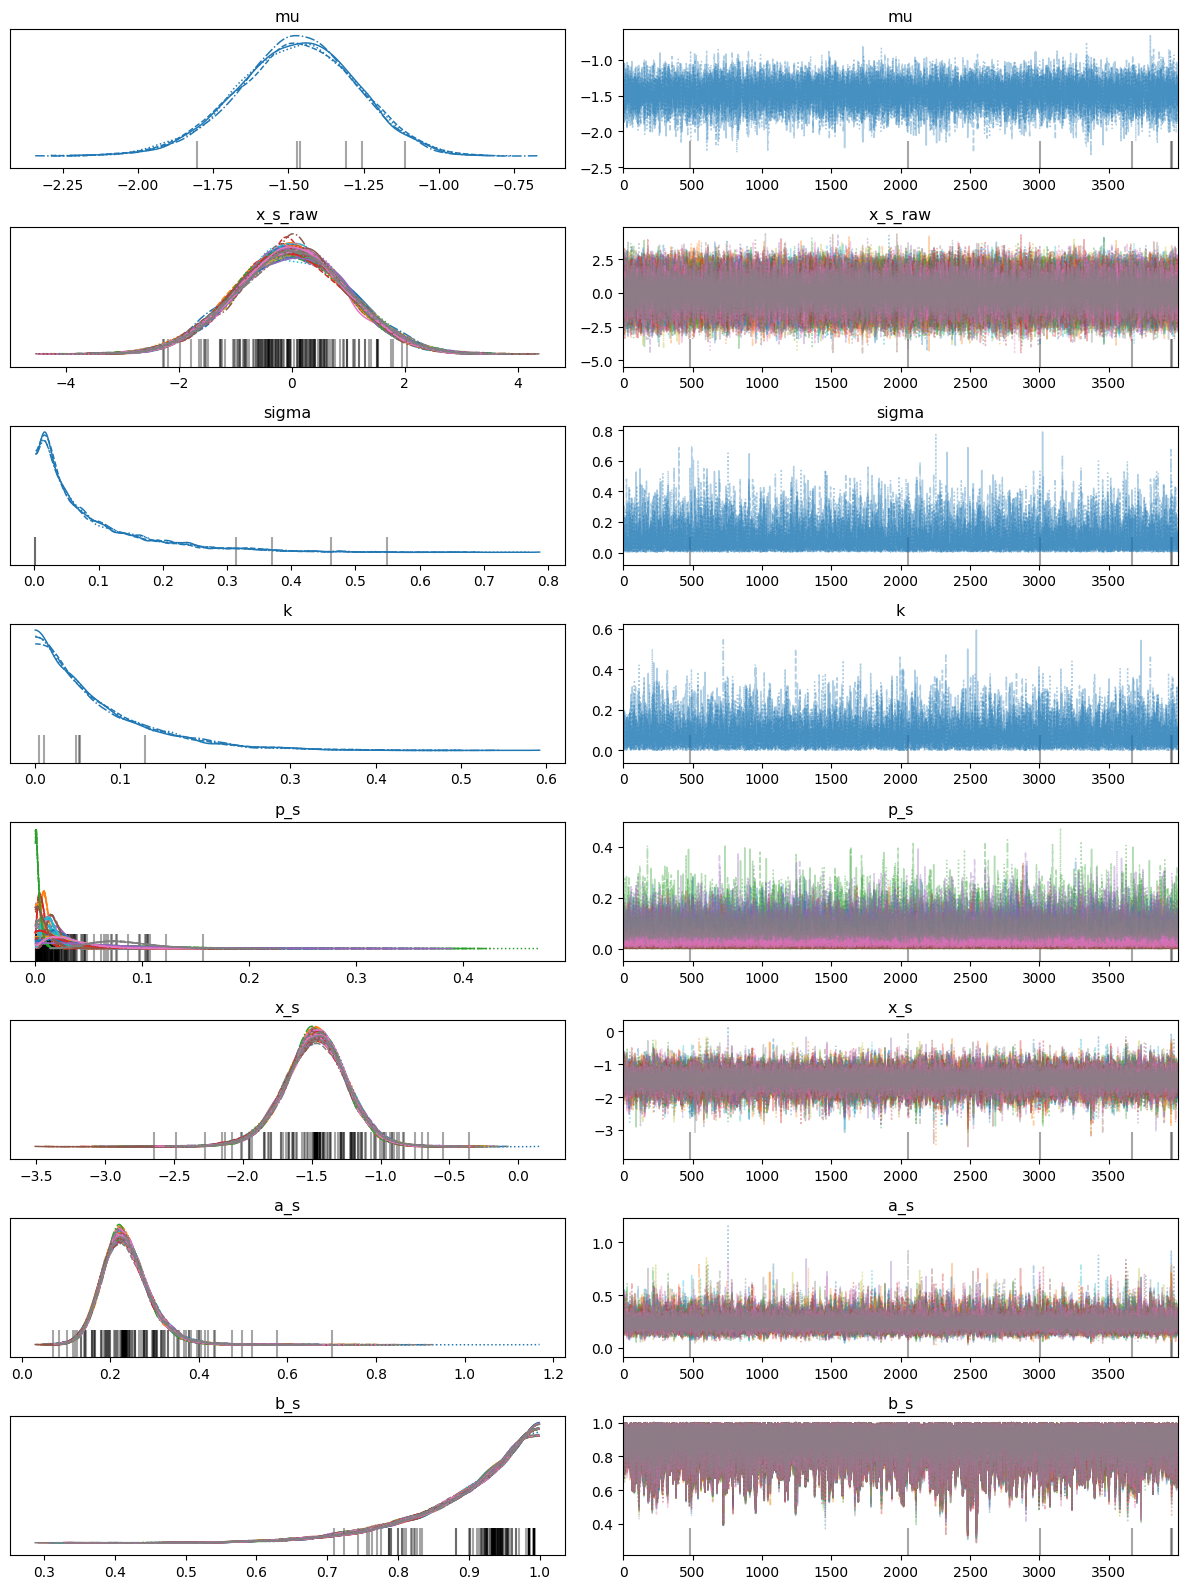

In [25]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

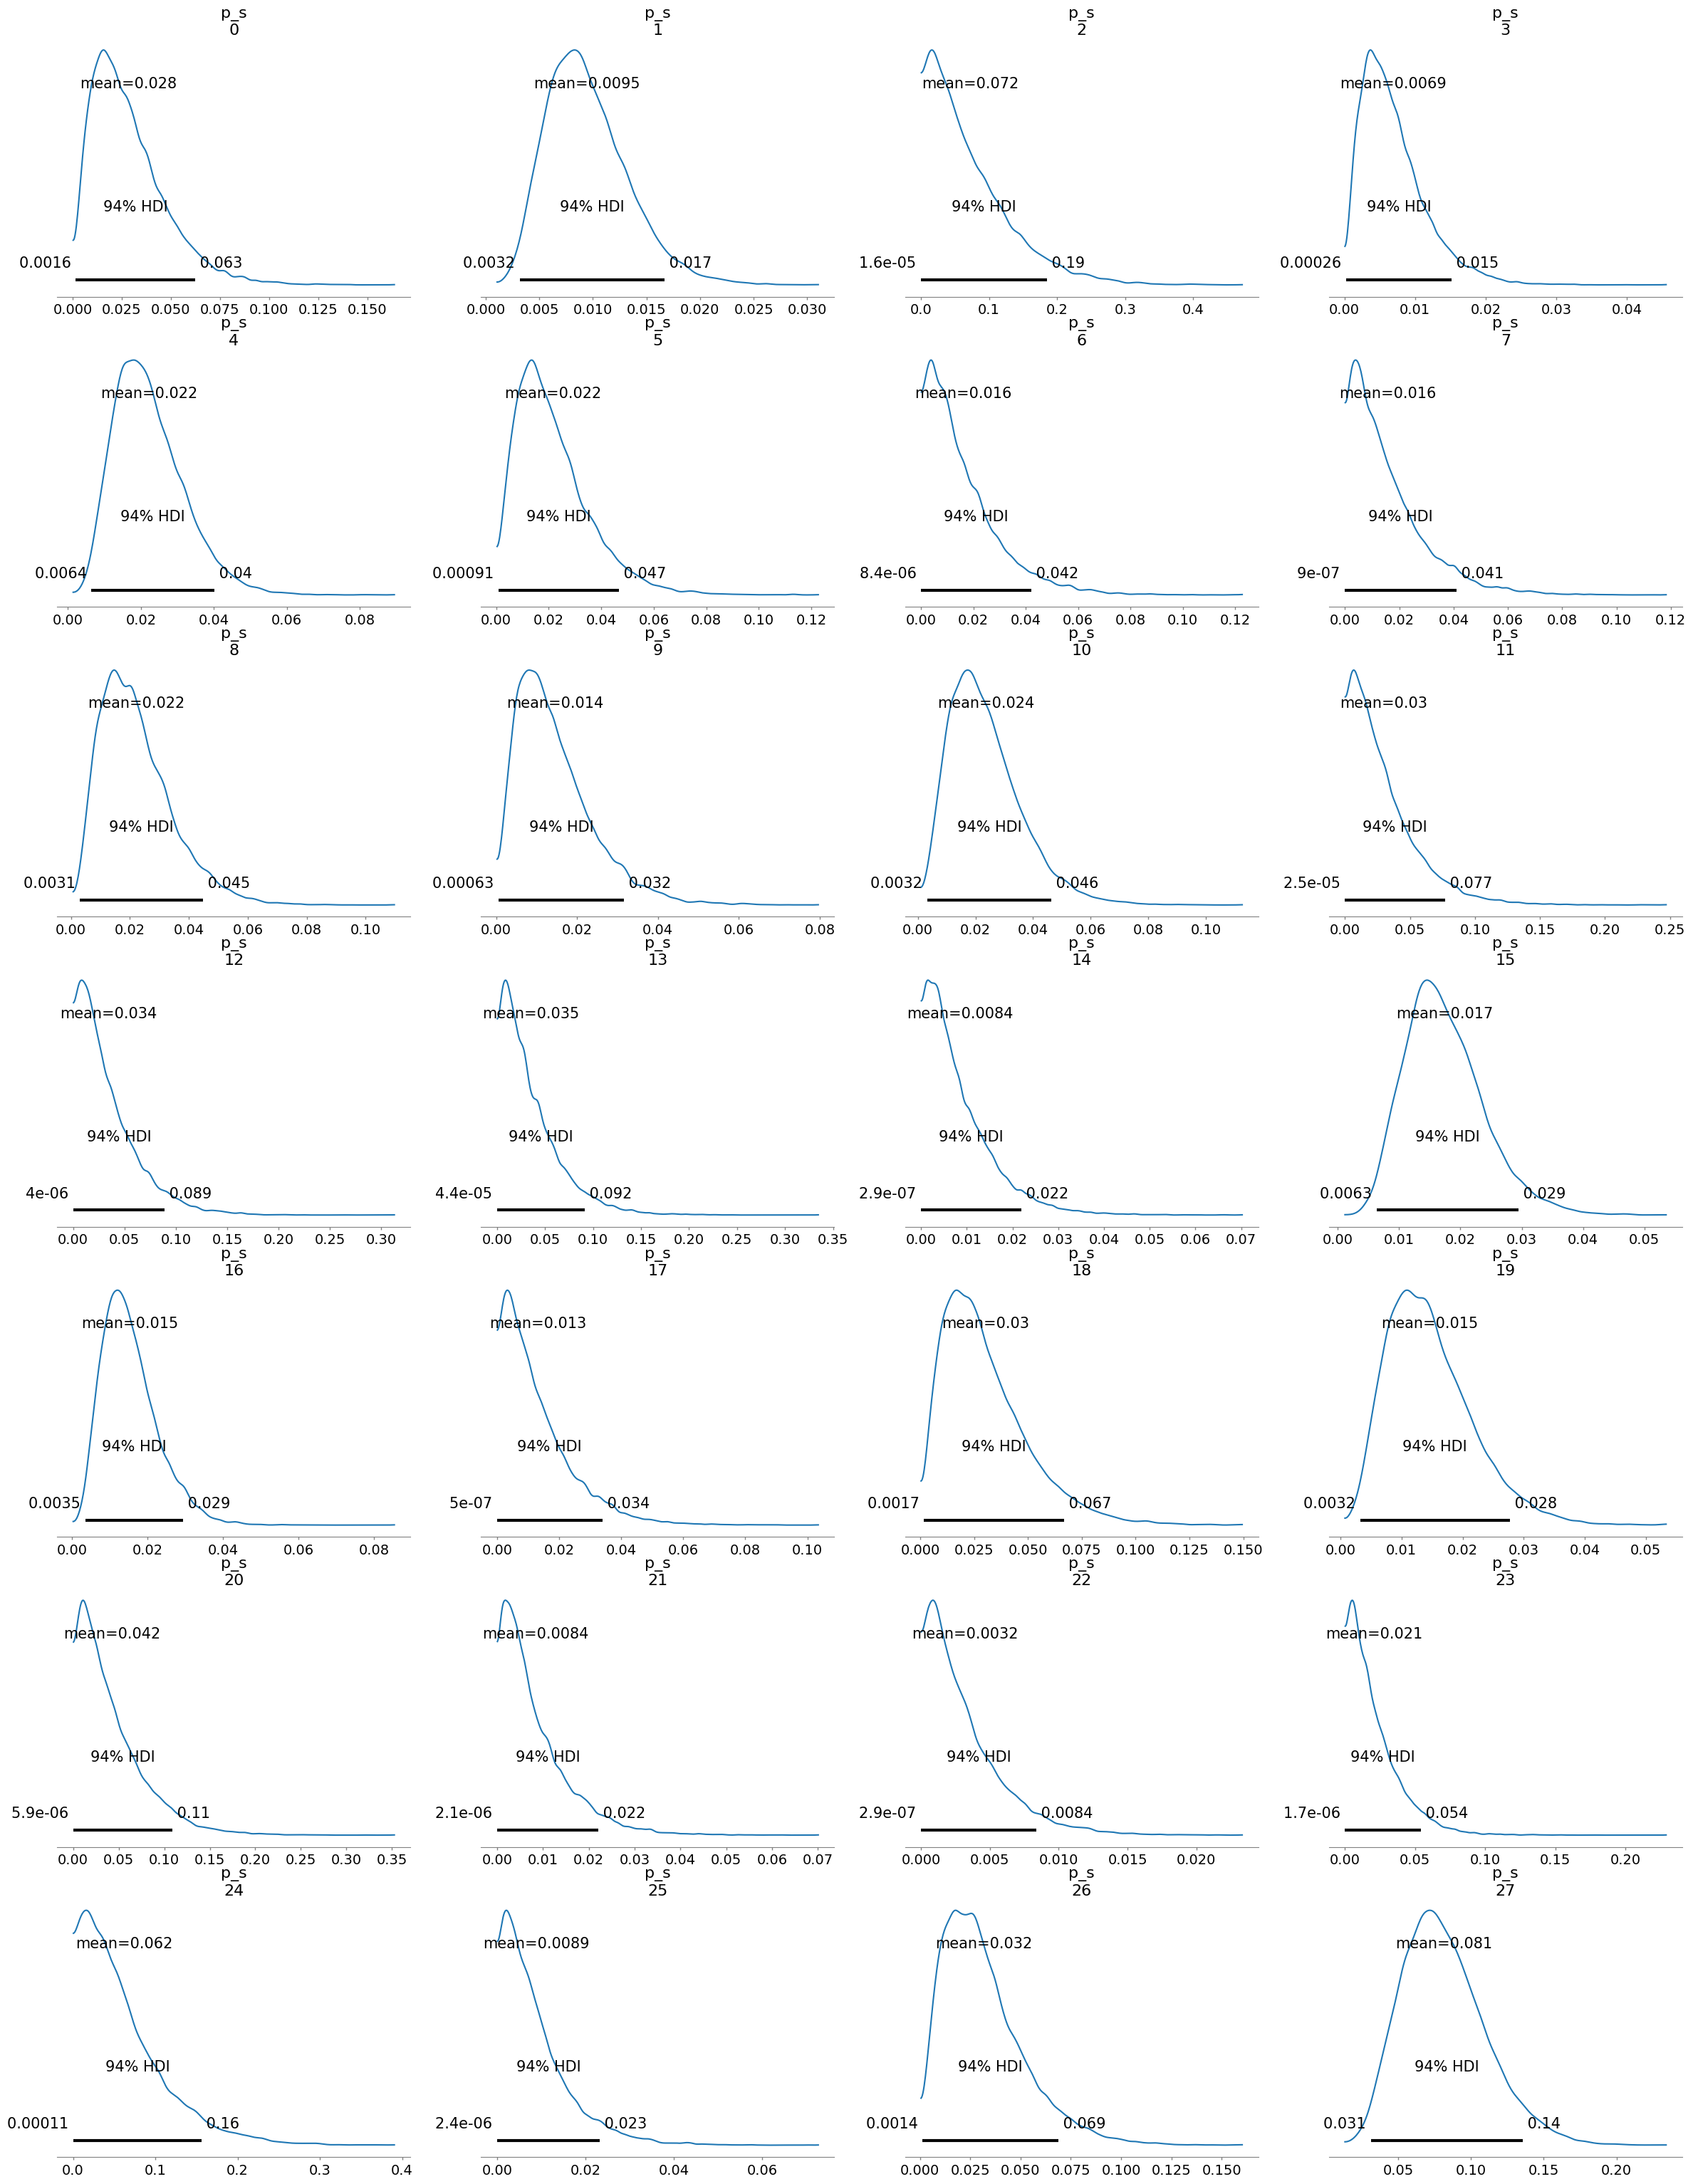

In [26]:
az.plot_posterior(trace, var_names=['p_s'])
plt.show()

In [27]:
n_s = df.groupby('region')['totalByRegion_2020'].mean().round(0).astype(int)
y_s = df['region'].value_counts()

all_regions = pd.Index(list(n_s.index) + list(y_s.index)).unique()
n_s = n_s.reindex(all_regions)
y_s = y_s.reindex(all_regions)

trace = az.from_netcdf('traces/trace_multilayer_region.nc')
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-1.696,0.607,-2.848,-0.624,0.007,0.010,9847.0,5733.0,1.0
x_s_raw[0],0.015,0.965,-1.825,1.822,0.007,0.008,16756.0,11726.0,1.0
x_s_raw[1],0.015,0.965,-1.775,1.865,0.008,0.008,15599.0,11030.0,1.0
x_s_raw[2],-0.027,0.955,-1.748,1.845,0.008,0.008,16100.0,11381.0,1.0
x_s_raw[3],-0.012,0.978,-1.874,1.803,0.008,0.009,15902.0,10425.0,1.0
sigma,0.262,0.416,0.001,0.935,0.006,0.017,9336.0,6125.0,1.0
k,0.254,0.207,0.000,0.631,0.002,0.002,8811.0,5236.0,1.0
p_s[0],0.020,0.004,0.013,0.027,0.000,0.000,17652.0,10643.0,1.0
p_s[1],0.015,0.004,0.009,0.021,0.000,0.000,15882.0,11066.0,1.0
p_s[2],0.006,0.002,0.003,0.009,0.000,0.000,16474.0,9940.0,1.0


In [28]:
a_post_samples = trace.posterior['a_s'].values + y_s.values[None, None, :] # Shape: (chains, draws, states)
b_post_samples = trace.posterior['b_s'].values + (n_s.values - y_s.values)[None, None, :]

post_means = a_post_samples.mean(axis=(0, 1)) / (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))
post_vars = (a_post_samples.mean(axis=(0, 1)) * b_post_samples.mean(axis=(0, 1))) / (
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))**2 * 
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)) + 1)
)

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post_samples.mean(axis=(0, 1)),
    'b_post': b_post_samples.mean(axis=(0, 1)),
    'post_mean': post_means,
    'post_var': post_vars
}, index=all_regions).reset_index().rename(columns={'index': 'region'})

print(results)

      region   n_s  y_s     a_post       b_post  post_mean  post_var
0    Midwest  1322   26  26.221420  1296.695703   0.019821  0.000015
1  Northeast  1163   17  17.220526  1146.695517   0.014795  0.000013
2      South  2054   12  12.216307  2042.693075   0.005945  0.000003
3       West  1254   10  10.217332  1244.693689   0.008142  0.000006


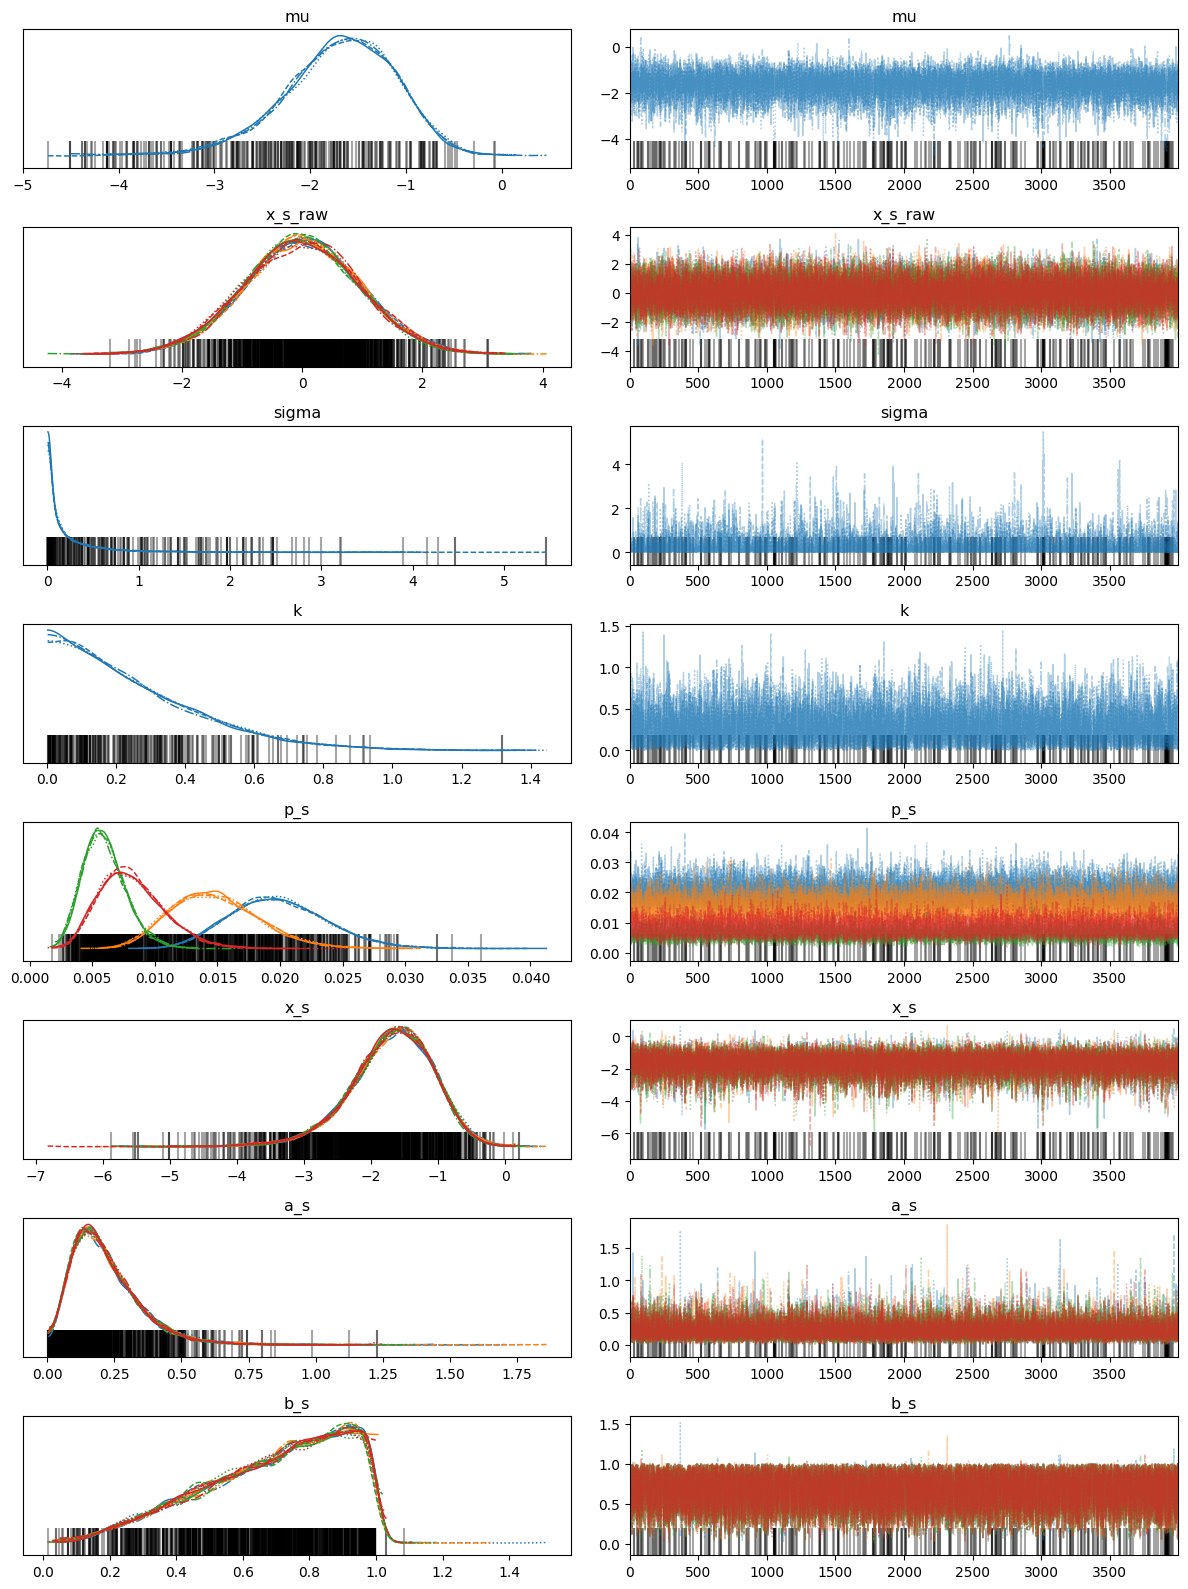

In [29]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

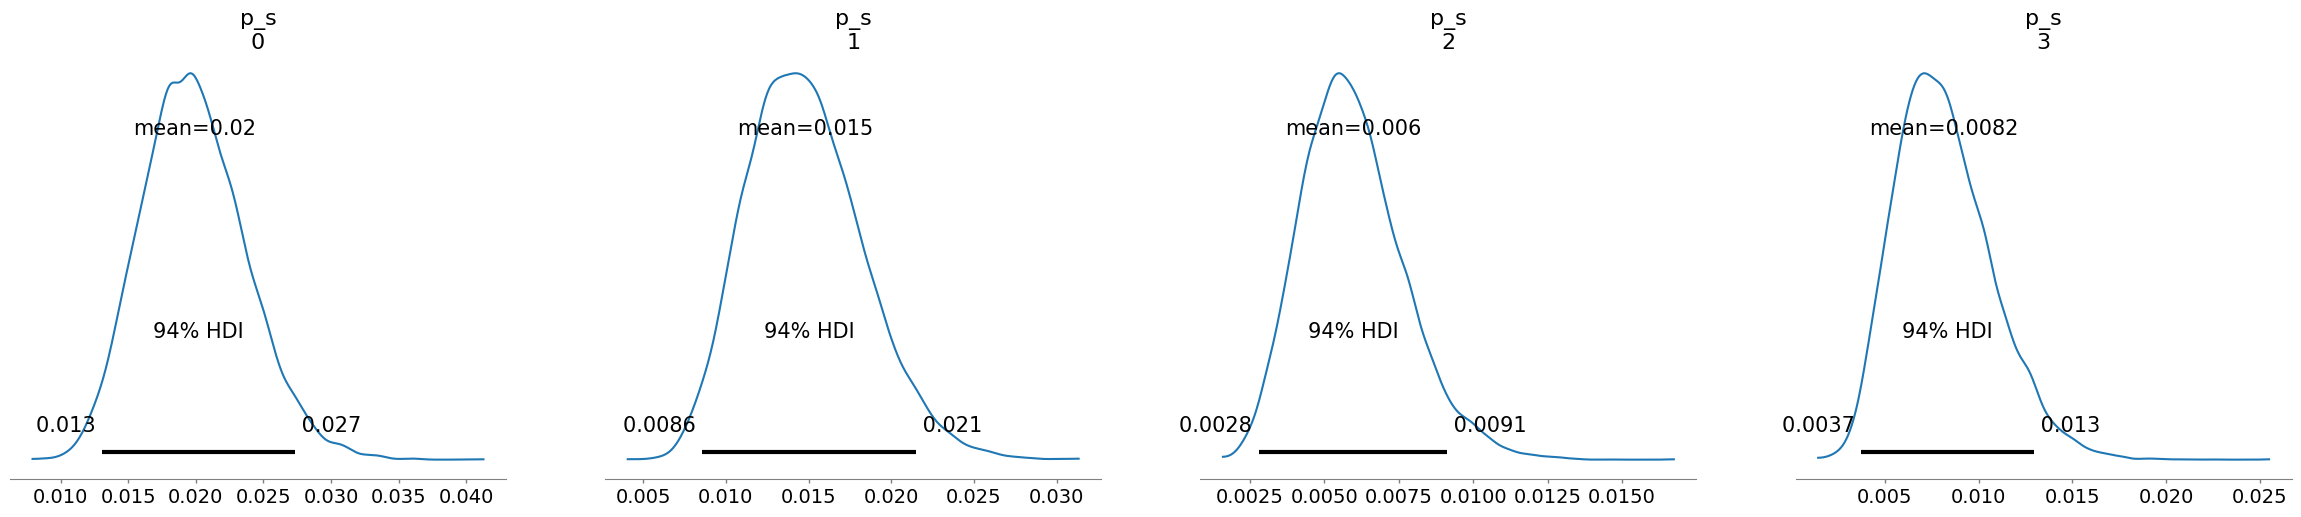

In [30]:
az.plot_posterior(trace, var_names=['p_s'])
plt.show()

## BHM (2 Layer)

In [33]:
n_s = df.groupby('state')['totalByState_2020'].mean().round(0).astype(int)
y_s = df['state'].value_counts()

all_states = pd.Index(list(n_s.index) + list(y_s.index)).unique()
n_s = n_s.reindex(all_states)
y_s = y_s.reindex(all_states)

trace = az.from_netcdf('traces/trace_simple_state.nc')
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_s[0],1.066,1.873,0.000,3.825,0.016,0.065,10337.0,9923.0,1.0
a_s[1],0.552,0.790,0.000,1.825,0.006,0.018,11998.0,9392.0,1.0
a_s[2],2.192,4.629,0.000,8.169,0.044,0.190,8434.0,9451.0,1.0
a_s[3],0.454,0.654,0.000,1.495,0.005,0.017,13380.0,9371.0,1.0
a_s[4],0.921,1.445,0.000,3.163,0.012,0.037,10761.0,9906.0,1.0
...,...,...,...,...,...,...,...,...,...
p_s[23],0.021,0.019,0.000,0.055,0.000,0.000,20100.0,8892.0,1.0
p_s[24],0.063,0.053,0.000,0.161,0.000,0.001,19337.0,9280.0,1.0
p_s[25],0.009,0.008,0.000,0.023,0.000,0.000,18708.0,8346.0,1.0
p_s[26],0.032,0.021,0.001,0.071,0.000,0.000,23801.0,9421.0,1.0


In [34]:
a_post_samples = trace.posterior['a_s'].values + y_s.values[None, None, :]  # Shape: (chains, draws, states)
b_post_samples = trace.posterior['b_s'].values + (n_s.values - y_s.values)[None, None, :]

post_means = a_post_samples.mean(axis=(0, 1)) / (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))
post_vars = (a_post_samples.mean(axis=(0, 1)) * b_post_samples.mean(axis=(0, 1))) / (
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))**2 * 
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)) + 1)
)

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post_samples.mean(axis=(0, 1)),
    'b_post': b_post_samples.mean(axis=(0, 1)),
    'post_mean': post_means,
    'post_var': post_vars
}, index=all_states).reset_index().rename(columns={'index': 'state'})

print(results)

            state  n_s  y_s    a_post      b_post  post_mean  post_var
0         Alabama   78    2  3.066437  105.624676   0.028212  0.000250
1      California  658    6  6.551534  684.225121   0.009484  0.000014
2        Delaware   16    1  3.191996   41.706395   0.071094  0.001439
3         Florida  320    2  2.454393  349.101613   0.006982  0.000020
4        Illinois  235    5  5.921277  260.806857   0.022200  0.000081
5         Indiana  102    2  2.897628  130.179564   0.021774  0.000159
6            Iowa   75    1  1.746930  104.972458   0.016369  0.000149
7        Maryland   77    1  1.726753  106.605581   0.015939  0.000143
8   Massachusetts  144    3  3.909332  171.697834   0.022262  0.000123
9        Michigan  154    2  2.682896  182.505361   0.014487  0.000077
10       Missouri  136    3  3.959799  163.517682   0.023644  0.000137
11       Nebraska   40    1  2.100490   68.038774   0.029947  0.000408
12         Nevada   35    1  2.200763   62.736128   0.033891  0.000497
13  Ne

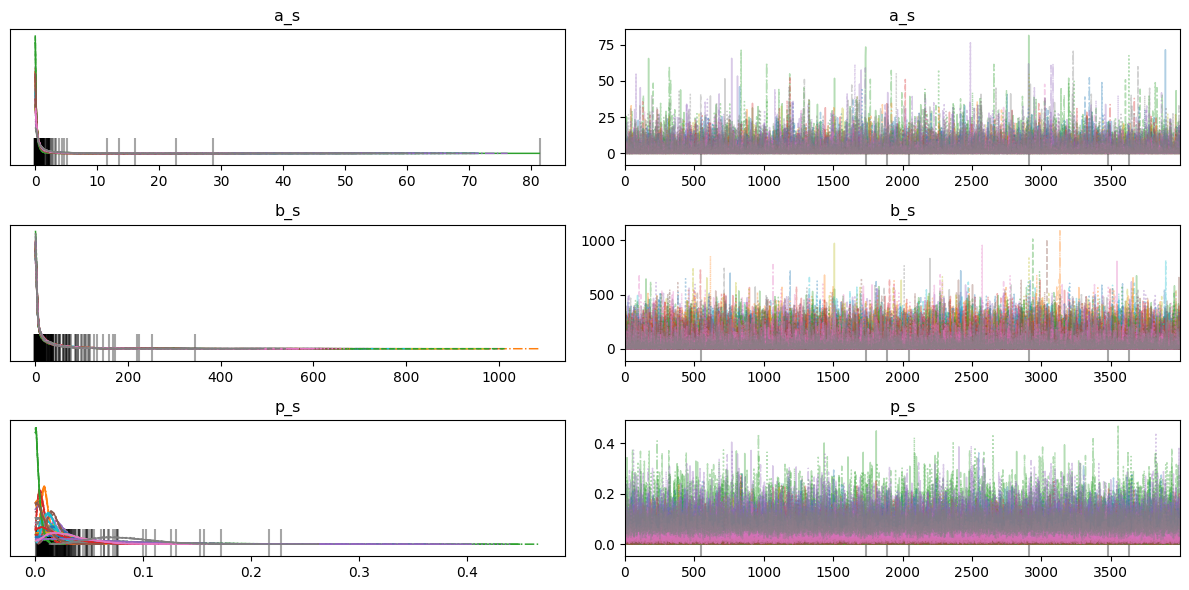

In [35]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

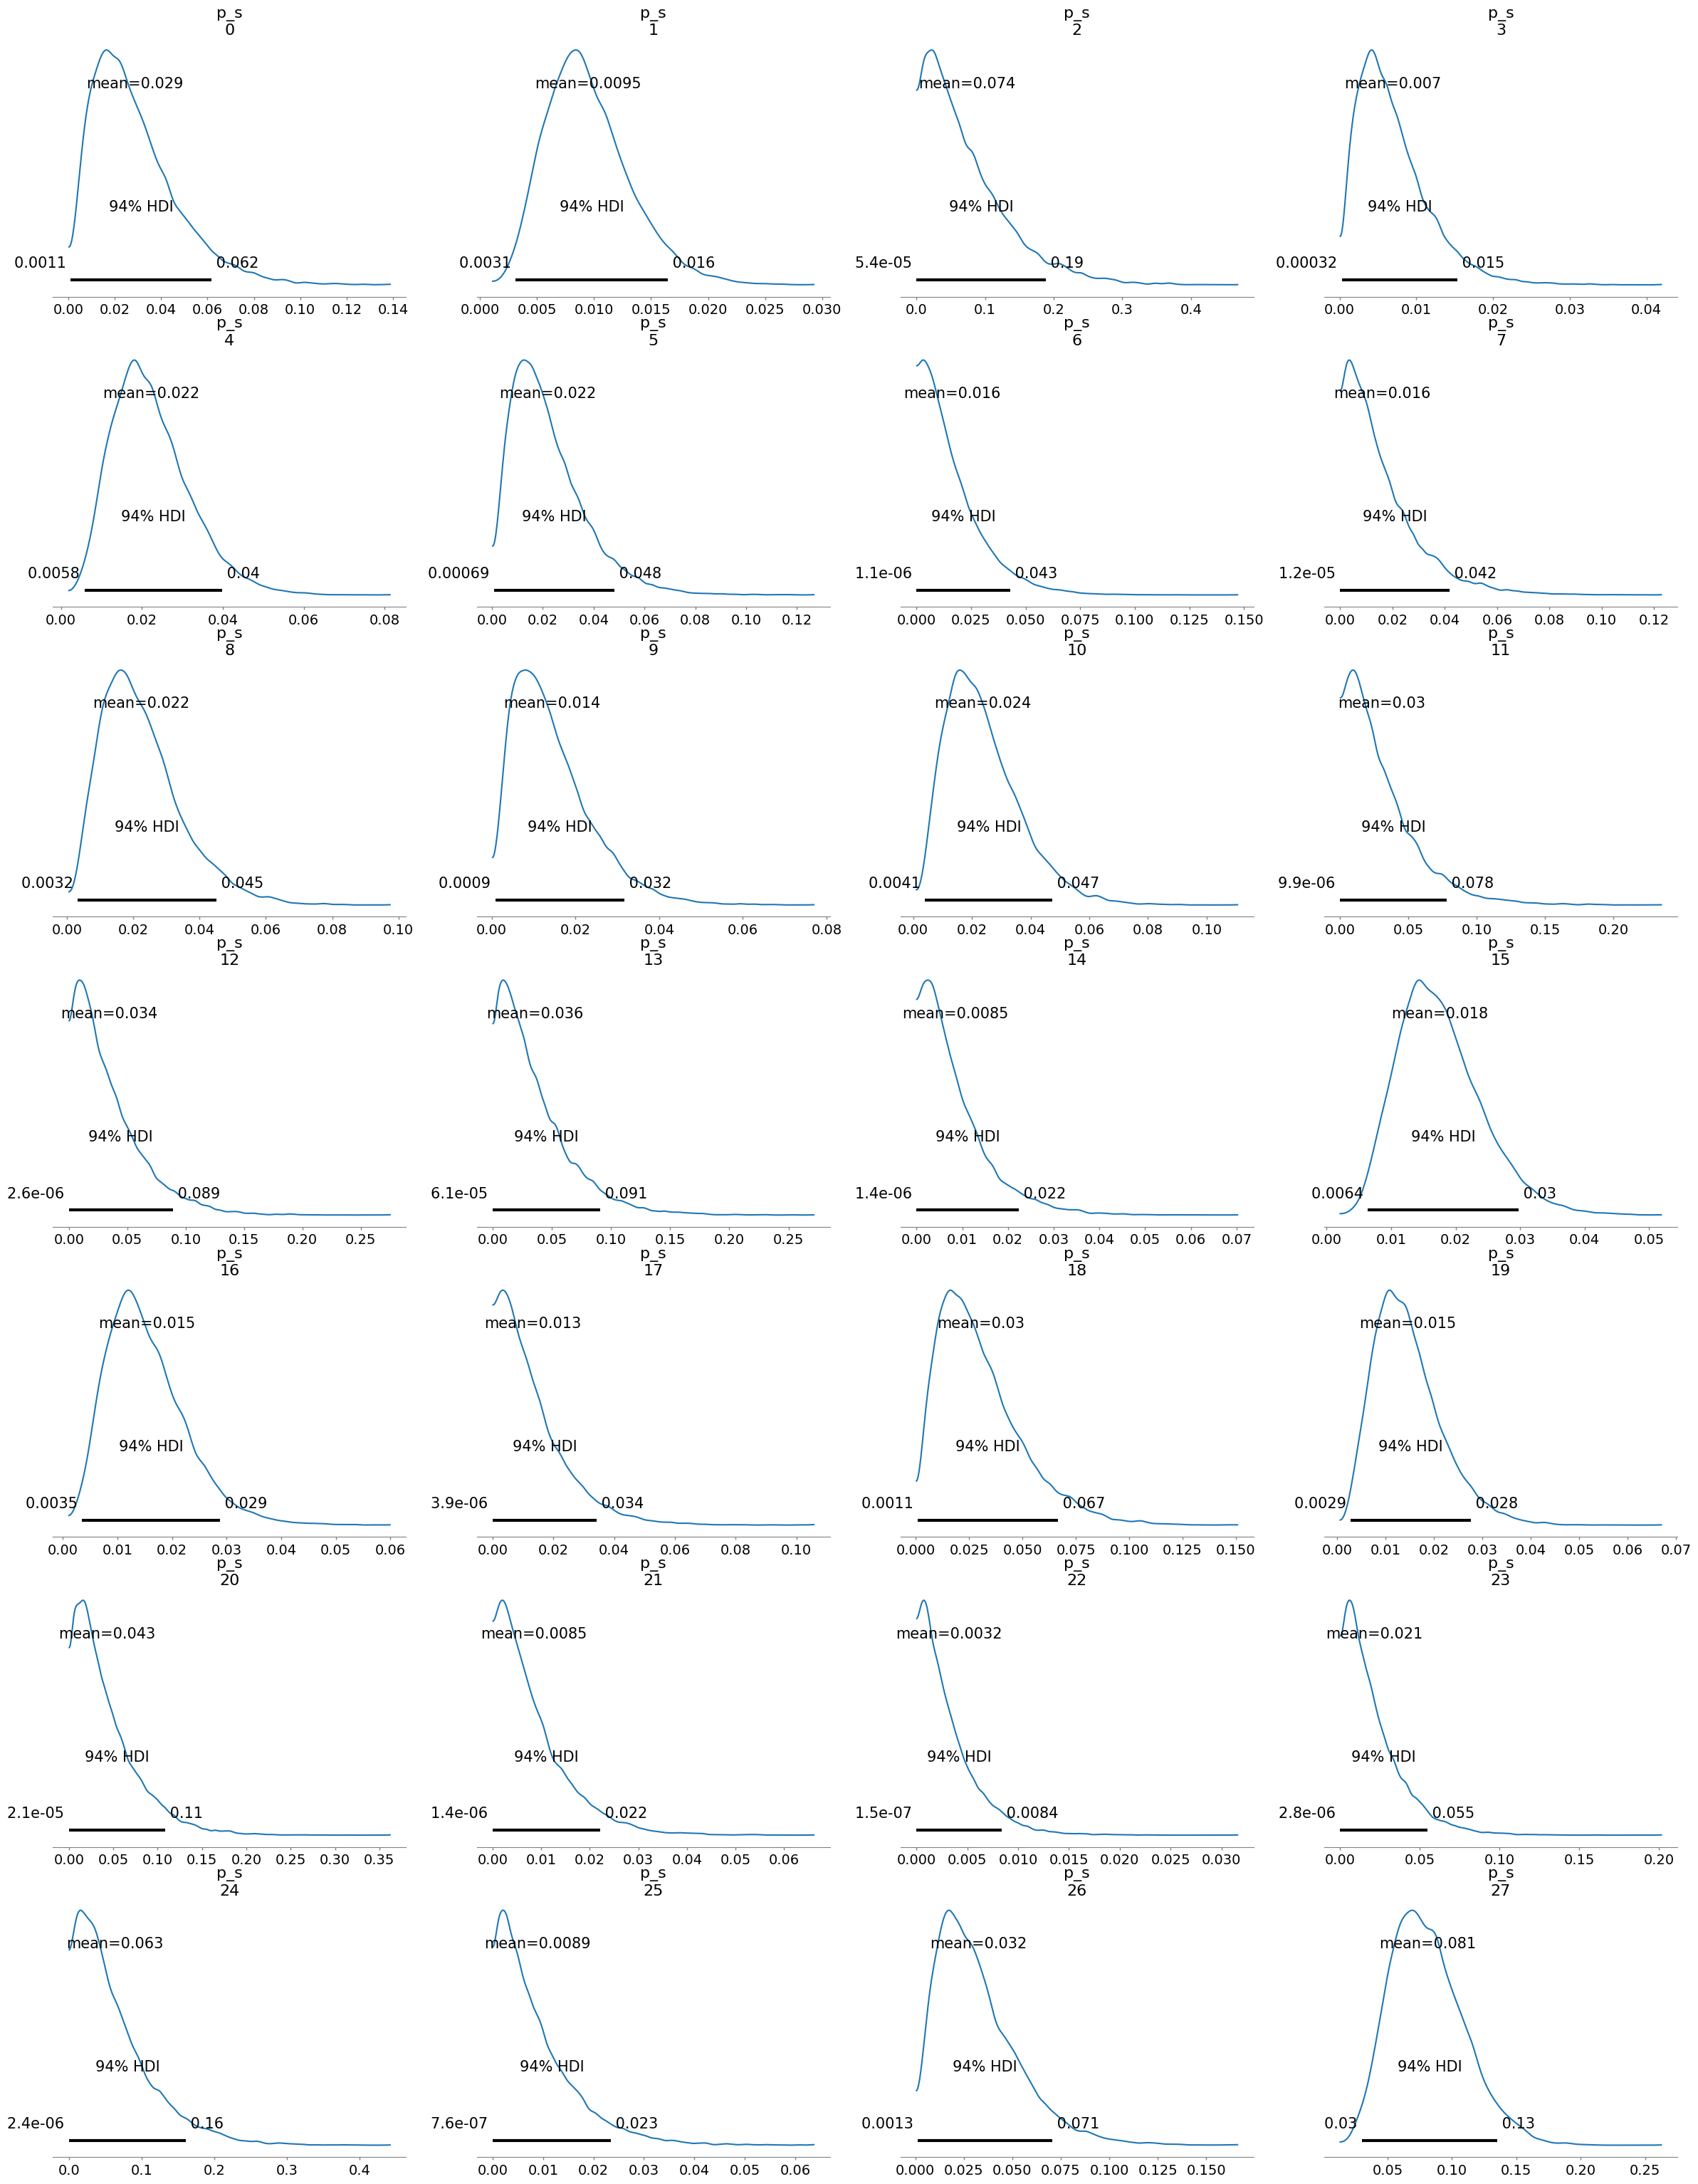

In [36]:
az.plot_posterior(trace, var_names=['p_s'])
plt.show()

In [37]:
n_s = df.groupby('region')['totalByRegion_2020'].mean().round(0).astype(int)
y_s = df['region'].value_counts()

all_regions = pd.Index(list(n_s.index) + list(y_s.index)).unique()
n_s = n_s.reindex(all_regions)
y_s = y_s.reindex(all_regions)

trace = az.from_netcdf('traces/trace_simple_region.nc')
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_s[0],0.824,1.217,0.000,2.874,0.011,0.025,7780.0,7376.0,1.0
a_s[1],0.726,1.023,0.000,2.430,0.009,0.020,7947.0,7385.0,1.0
a_s[2],0.433,0.578,0.000,1.431,0.005,0.010,7921.0,7015.0,1.0
a_s[3],0.511,0.713,0.000,1.695,0.007,0.014,6907.0,6357.0,1.0
b_s[0],29.576,49.564,0.000,115.578,0.439,0.966,8843.0,8732.0,1.0
b_s[1],31.877,52.440,0.000,125.647,0.445,0.955,8899.0,8173.0,1.0
b_s[2],31.702,55.396,0.000,128.828,0.447,0.939,8687.0,8096.0,1.0
b_s[3],32.497,55.024,0.000,129.386,0.453,0.882,8652.0,8361.0,1.0
p_s[0],0.020,0.004,0.013,0.027,0.000,0.000,14171.0,9869.0,1.0
p_s[1],0.015,0.004,0.009,0.022,0.000,0.000,13928.0,10199.0,1.0


In [38]:
a_post_samples = trace.posterior['a_s'].values + y_s.values[None, None, :] # Shape: (chains, draws, states)
b_post_samples = trace.posterior['b_s'].values + (n_s.values - y_s.values)[None, None, :]

post_means = a_post_samples.mean(axis=(0, 1)) / (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))
post_vars = (a_post_samples.mean(axis=(0, 1)) * b_post_samples.mean(axis=(0, 1))) / (
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)))**2 * 
    (a_post_samples.mean(axis=(0, 1)) + b_post_samples.mean(axis=(0, 1)) + 1)
)

results = pd.DataFrame({
    'n_s': n_s,
    'y_s': y_s,
    'a_post': a_post_samples.mean(axis=(0, 1)),
    'b_post': b_post_samples.mean(axis=(0, 1)),
    'post_mean': post_means,
    'post_var': post_vars
}, index=all_regions).reset_index().rename(columns={'index': 'region'})

print(results)

      region   n_s  y_s     a_post       b_post  post_mean  post_var
0    Midwest  1322   26  26.824268  1325.575703   0.019835  0.000014
1  Northeast  1163   17  17.726381  1177.877097   0.014826  0.000012
2      South  2054   12  12.433179  2073.701741   0.005960  0.000003
3       West  1254   10  10.511087  1276.496824   0.008167  0.000006


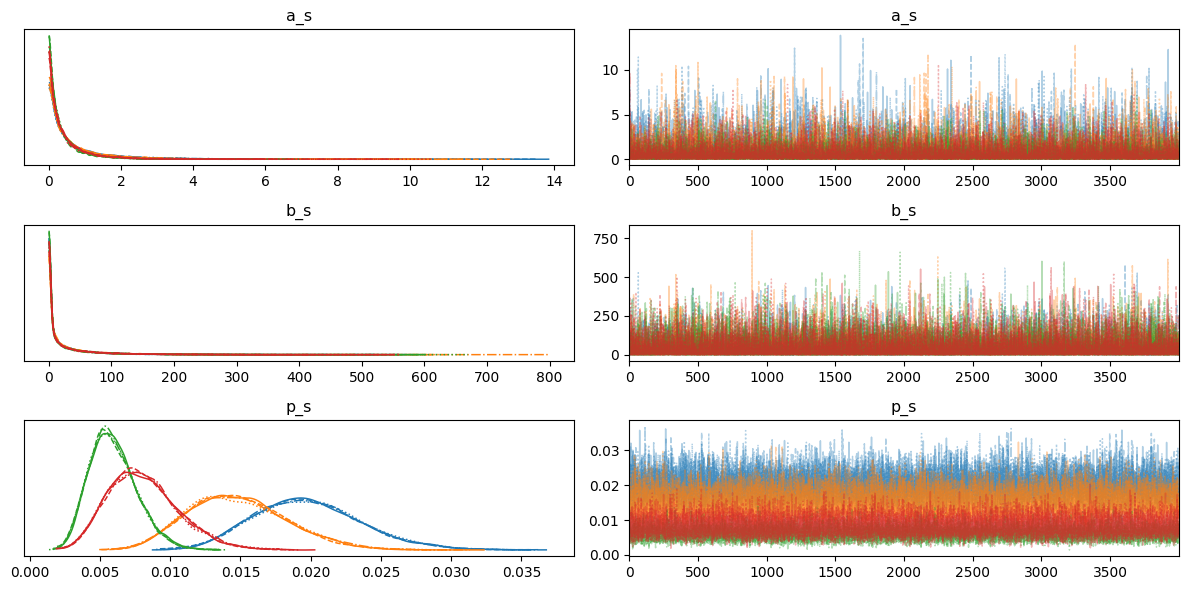

In [39]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

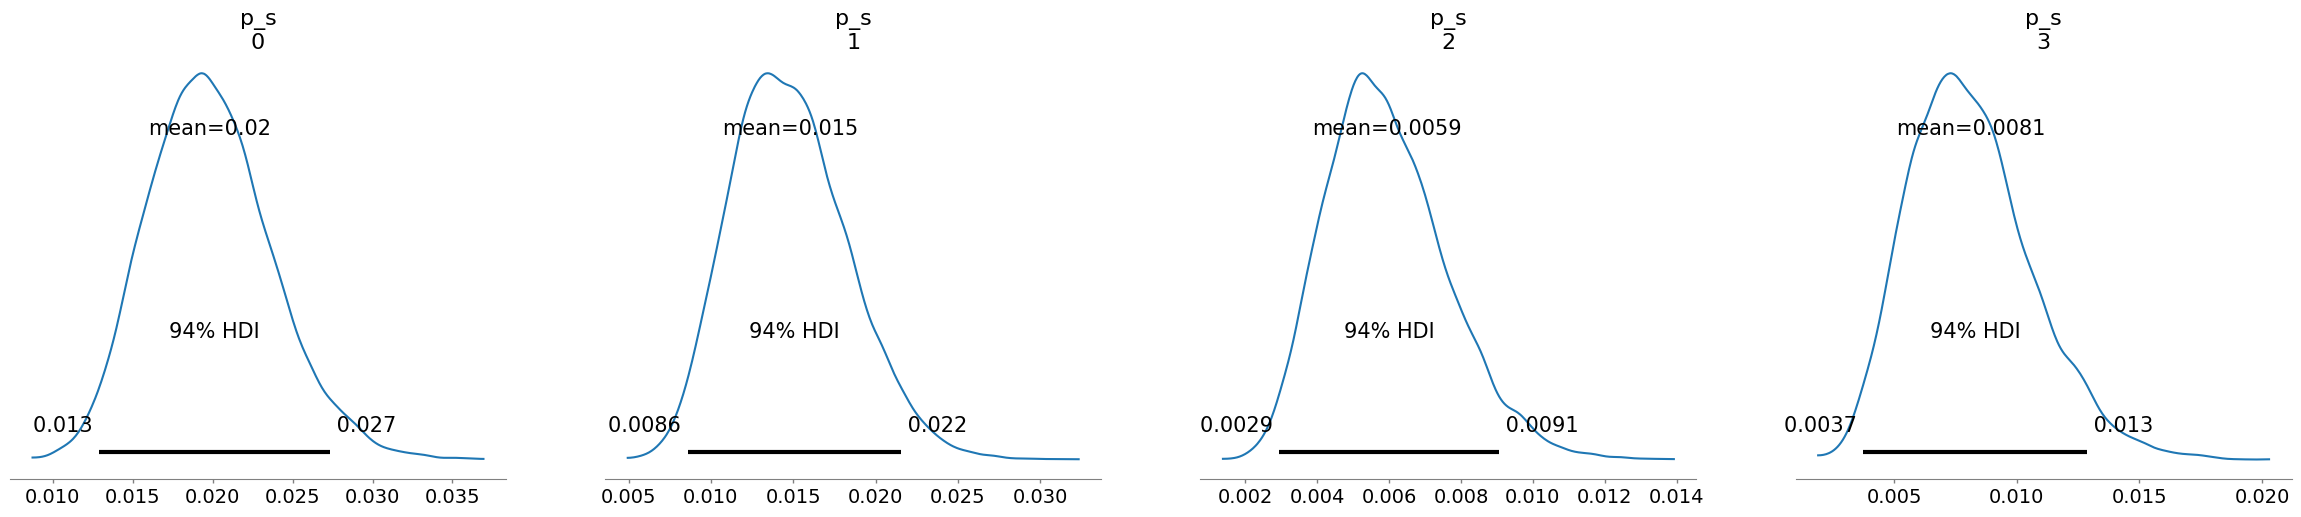

In [40]:
az.plot_posterior(trace, var_names=['p_s'])
plt.show()